In [30]:
import os
import sys

module_path = os.path.abspath(os.path.join(".."))
if module_path not in sys.path:
    sys.path.append(module_path)

In [ ]:
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont, ImageFilter
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import random
import tensorflow as tf
import cv2

from src.font import FONT_PATHS, FONT_TO_LABEL, LABEL_TO_FONT_NAME

In [32]:
# Get the project directory
PROJECT_DIR = Path.cwd().parents[0]

In [33]:
# Sizes
IMG_SIZE = 64
BATCH_SIZE = 32

In [34]:
# Digits from 1 to 9
DIGITS = list(range(1, 10))

In [35]:
# The paths of the fonts
NUM_CLASSES = len(FONT_TO_LABEL)

In [36]:
def generate_digit_image(digit: int) -> tuple[np.ndarray, int]:
    """
    Generates a given digit on the image with random augmentation.

    Args:
        digit: The given digit

    Returns:
        tuple:
            np.ndarray: The image
            int: The label of the image (zero-based index)
    """

    def scale_font_to_target(draw, font_path, text, target_scale=0.8):
        target = IMG_SIZE * target_scale

        font = ImageFont.truetype(font_path, 10)

        for _ in range(10):
            left, top, right, bottom = draw.textbbox((0, 0), text, font=font)
            w, h = right - left, bottom - top

            scale = target / max(w, h)
            new_size = int(font.size * scale)

            if abs(scale - 1.0) < 0.05:
                break

            font = ImageFont.truetype(font_path, max(10, min(new_size, 300)))

        return font

    # Create a greyscale image in grey mode
    img = Image.new("L", (IMG_SIZE, IMG_SIZE), 255)
    draw = ImageDraw.Draw(img)

    # Select a random font
    font_path = random.choice(FONT_PATHS)

    font_label = FONT_TO_LABEL[font_path]

    # Conver the digit to string format
    text = str(digit)

    font = scale_font_to_target(draw, font_path, text, target_scale=0.8)

    # Find the width and height of the text bounding box
    left, top, right, bottom = draw.textbbox((0, 0), text, font=font)
    w = right - left
    h = bottom - top

    # Determine the position of the text
    x = (IMG_SIZE - w) // 2 + random.randint(-5, 5)
    y = (IMG_SIZE - h) // 2 + random.randint(-5, 5)

    draw.text((x, y), text, fill='black', font=font)

    # Blur the image
    if random.random() < 0.4:
        img = img.filter(ImageFilter.GaussianBlur(random.uniform(0, 1.5)))

    # Convert the image to an array
    arr = np.array(img).astype(np.float32)

    # Invert the image
    arr = 255.0 - arr

    # Apply noises
    if random.random() < 0.5:
        arr += np.random.normal(0, 20, arr.shape)

    # Clip all pixels of the image between 0 and 255
    arr = np.clip(arr, 0, 255)

    # Convert the image to RGB
    arr = np.stack([arr, arr, arr], axis=-1)

    return arr.astype(np.float32), font_label

In [37]:
def data_generator():
    """
    Data generator wrapper that yields an RGB image and its label

    Yields:
        tuple:
            np.ndarray: An RGB image that contains an augmented digit
            int: The label of the image (zero-based index)
    """

    while True:
        digit = random.choice(DIGITS)
        img, label = generate_digit_image(digit)
        yield img, label

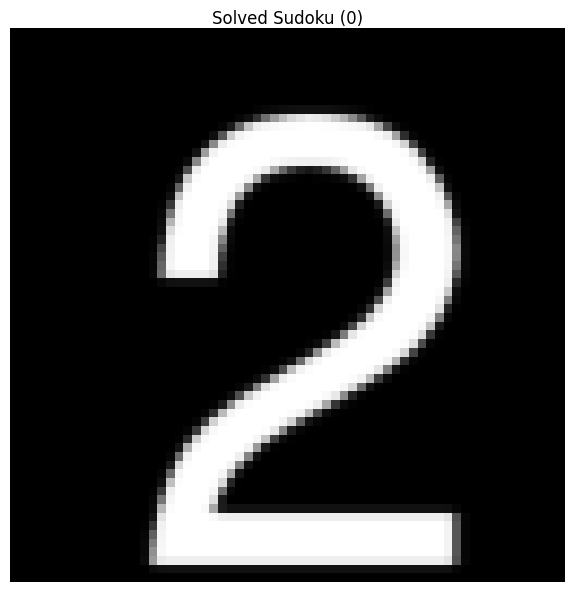

In [38]:
fig, ax = plt.subplots(figsize=(6, 6))
img, label= generate_digit_image(2)
img = img.astype(np.uint8)
ax.imshow(img)
ax.set_title(f"Example of A Slice of Training Dataset ({LABEL_TO_FONT_NAME[label]})", pad=2)
ax.axis('off')

plt.tight_layout(pad=1.0)
plt.show()

In [39]:
# Describe what the custom generator will yield
output_signature = (
    tf.TensorSpec(shape=(IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32), # the image
    tf.TensorSpec(shape=(), dtype=tf.int32) # the label
)

# Create the training dataset from the generator
train_ds = tf.data.Dataset.from_generator(
    data_generator,
    output_signature=output_signature
)

# Use prefetching to improve performance
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [40]:
# Create the training dataset from the generator
val_ds = tf.data.Dataset.from_generator(
    data_generator,
    output_signature=output_signature
)

val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [41]:
# Customize a model from the base MobileNetV2 model

# Define the input layer
inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Pass the input through MobileNetV2's specific scalar
x = keras.applications.mobilenet_v2.preprocess_input(inputs)

# Define the base model
base_model = keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = True

fine_tune_layers = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_layers]:
    layer.trainable = False

# Chain the tensor layers
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.3)(x)

# Define the output layer
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

# Create our custom model
model = keras.Model(inputs, outputs)

/var/folders/vb/gdmzt8xs5bb2rp7k5ht40ync0000gn/T/ipykernel_21638/3957955703.py:10: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


In [42]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Summary of the model
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,293 (8.93 MB)

 Trainable params: 1,608,709 (6.14 MB)

 Non-trainable params: 731,584 (2.79 MB)

In [43]:
# Create a callback to stop training when the improvement metric has stopped improving
callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', # set the improvement metric to value loss
    patience=3, # the number of epochs to wait
    restore_best_weights=True   # roll back the model to its best performance state
)

In [44]:
history = model.fit(
    train_ds,
    steps_per_epoch=200,
    epochs=20,
    callbacks=[callback]
)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.6295 - loss: 1.0601
Epoch 2/20
  3/200 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.7587 - loss: 0.5118

/Users/neil/Develop/SudoVisionCruncher/.venv/lib/python3.11/site-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.8345 - loss: 0.4651
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.8963 - loss: 0.3067
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.9098 - loss: 0.2520
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.9280 - loss: 0.2156
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.9445 - loss: 0.1769
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.9436 - loss: 0.1608
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.9506 - loss: 0.1425
Epoch 9/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.9527 - loss: 0.1356
Epoch 10/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.9527 - loss: 0.1360
Epoch 11/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.9572 - loss: 0.1248
Epoch 12/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.9584 - loss: 0.1194
Epoch 13/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/st

In [45]:
# Evaluate the model
test_loss, test_acc = model.evaluate(val_ds, steps=5, verbose=2)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")

5/5 - 1s - 248ms/step - accuracy: 0.9937 - loss: 0.0696

Test Accuracy: 99.37%


In [46]:
# Save the model and its parameters
model.save(f'{PROJECT_DIR}/models/font_recognition_MobileNetV2.keras')